In [2]:
import pandas as pd

df = pd.read_csv("/home/abishek-murugan/Project Folder/GUVI Projects/EcoType-Forest-Cover/data/raw/dataset.csv")

In [3]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [4]:
df.tail()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
145885,2834,88,8,376,44,2552,232,227,128,1595,Lodgepole Pine,1,29
145886,2832,68,4,390,44,2522,224,231,142,1572,Lodgepole Pine,1,29
145887,2829,80,7,390,33,2492,229,228,133,1550,Lodgepole Pine,1,29
145888,2826,121,7,379,30,2462,232,234,135,1528,Lodgepole Pine,1,29
145889,2823,132,12,371,27,2432,239,234,123,1506,Lodgepole Pine,1,1


In [5]:
df.shape

(145890, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Cover_Type"].value_counts()

Cover_Type
Lodgepole Pine       103071
Spruce/Fir            31110
Aspen                  3069
Krummholz              2160
Ponderosa Pine         2160
Douglas-fir            2160
Cottonwood/Willow      2160
Name: count, dtype: int64

In [9]:
df["Cover_Type"].value_counts(normalize=True)*100

Cover_Type
Lodgepole Pine       70.649805
Spruce/Fir           21.324285
Aspen                 2.103640
Krummholz             1.480568
Ponderosa Pine        1.480568
Douglas-fir           1.480568
Cottonwood/Willow     1.480568
Name: proportion, dtype: float64

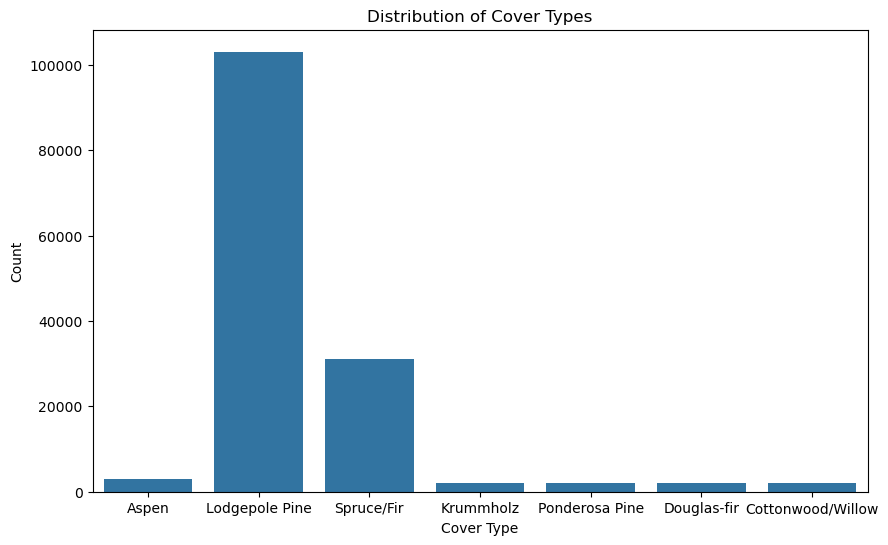

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(x='Cover_Type', data=df)
plt.title('Distribution of Cover Types')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.show()

### Handling Class Imbalance

##### The target variable shows significant class imbalance. However, resampling techniques such as RandomOverSampler or SMOTE will be applied only on the training dataset after train-test split to prevent data leakage and ensure fair model evaluation.


In [11]:
df["Wilderness_Area"].unique()

array([1, 3, 4, 2])

In [12]:
df["Soil_Type"].unique()

array([29, 12, 30, 18, 16, 20, 24, 23, 40, 19,  8, 22, 39,  9, 38, 33, 31,
       32, 11, 10,  5, 28,  4,  1, 13,  2, 17,  3, 34,  6, 14, 37, 35, 36,
       21, 26, 27, 25,  7])

In [13]:
import numpy as np

numerical_cols = [
    'Elevation',
    'Aspect',
    'Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am',
    'Hillshade_Noon',
    'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

In [14]:
def detect_outliers_iqr(df, columns):
    outlier_summary = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary[col] = len(outliers)

    return outlier_summary


outlier_counts = detect_outliers_iqr(df, numerical_cols)
outlier_counts

{'Elevation': 4448,
 'Aspect': 0,
 'Slope': 3385,
 'Horizontal_Distance_To_Hydrology': 2473,
 'Vertical_Distance_To_Hydrology': 7123,
 'Horizontal_Distance_To_Roadways': 0,
 'Hillshade_9am': 5242,
 'Hillshade_Noon': 3211,
 'Hillshade_3pm': 3087,
 'Horizontal_Distance_To_Fire_Points': 0}

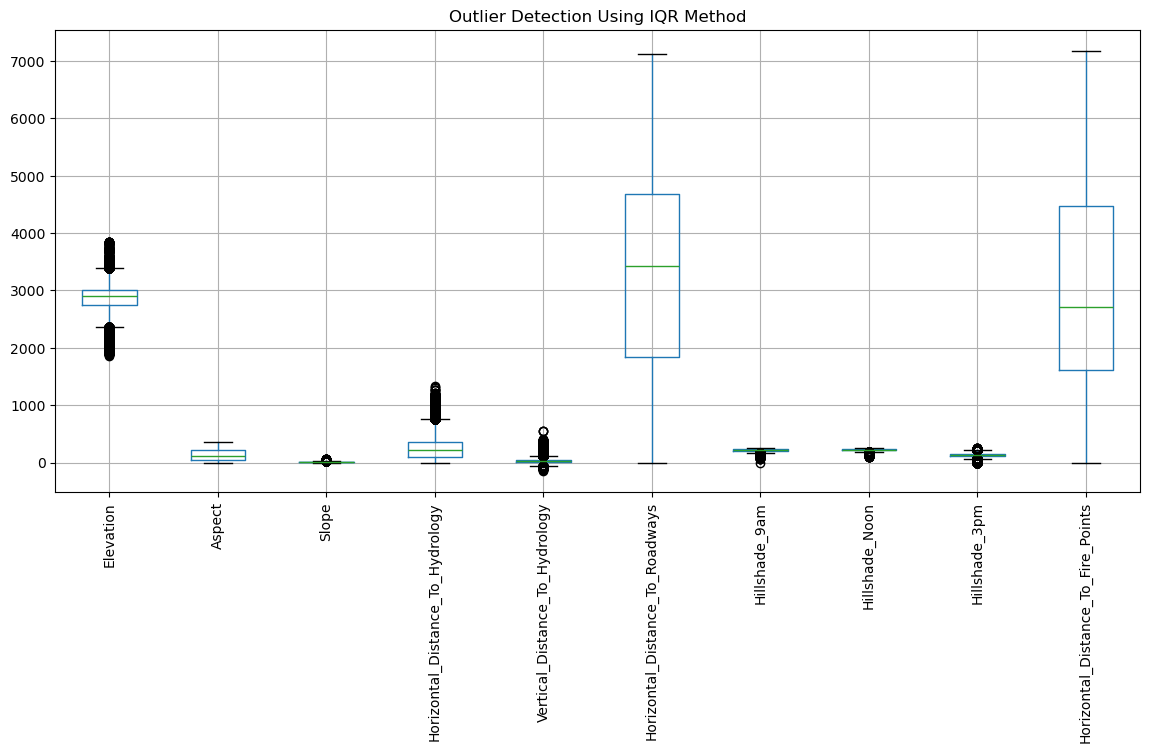

In [15]:
plt.figure(figsize=(14, 6))
df[numerical_cols].boxplot(rot=90)
plt.title("Outlier Detection Using IQR Method")
plt.show()

In [16]:
df[numerical_cols].skew()

Elevation                            -0.664497
Aspect                                0.689432
Slope                                 0.943937
Horizontal_Distance_To_Hydrology      0.984953
Vertical_Distance_To_Hydrology        1.792939
Horizontal_Distance_To_Roadways      -0.058240
Hillshade_9am                        -1.286839
Hillshade_Noon                       -0.945446
Hillshade_3pm                        -0.165213
Horizontal_Distance_To_Fire_Points    0.365249
dtype: float64

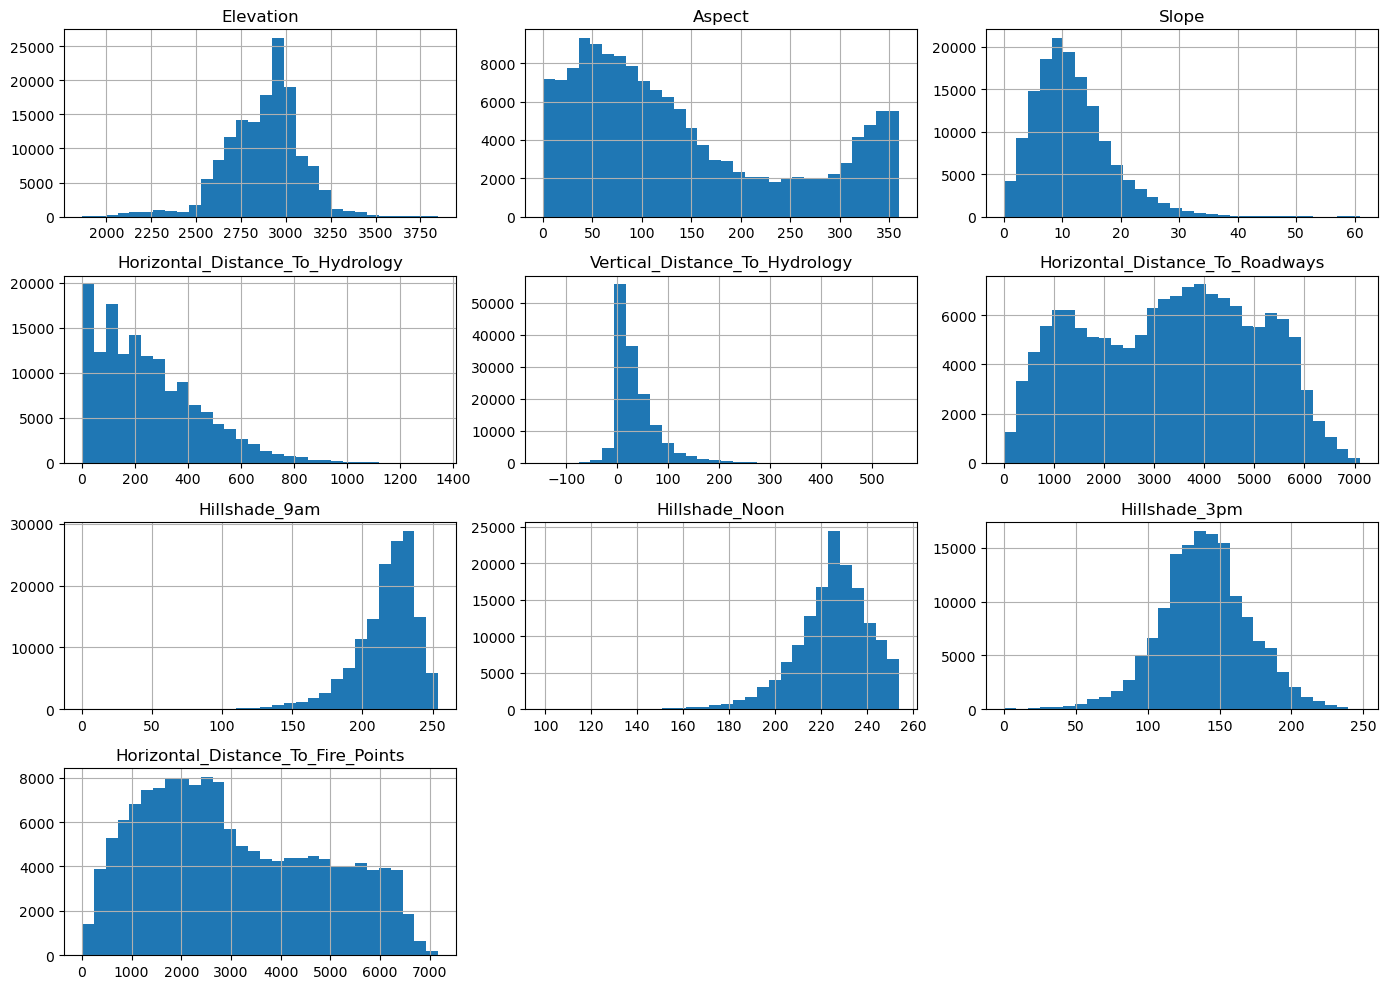

In [17]:
df[numerical_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

In [18]:
def cap_outliers(df, columns):
    df_capped = df.copy()

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_capped[col] = np.clip(df[col], lower, upper)

    return df_capped


df_capped = cap_outliers(df, numerical_cols)
df_capped

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596.0,51,3,258.0,0,510,221.0,232,148,6279,Aspen,1,29
1,2590.0,56,2,212.0,-6,390,220.0,235,151,6225,Aspen,1,29
2,2804.0,139,9,268.0,65,3180,234.0,238,135,6121,Lodgepole Pine,1,12
3,2785.0,155,18,242.0,117,3090,238.0,238,122,6211,Lodgepole Pine,1,30
4,2595.0,45,2,153.0,-1,391,220.0,234,150,6172,Aspen,1,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,2834.0,88,8,376.0,44,2552,232.0,227,128,1595,Lodgepole Pine,1,29
145886,2832.0,68,4,390.0,44,2522,224.0,231,142,1572,Lodgepole Pine,1,29
145887,2829.0,80,7,390.0,33,2492,229.0,228,133,1550,Lodgepole Pine,1,29
145888,2826.0,121,7,379.0,30,2462,232.0,234,135,1528,Lodgepole Pine,1,29


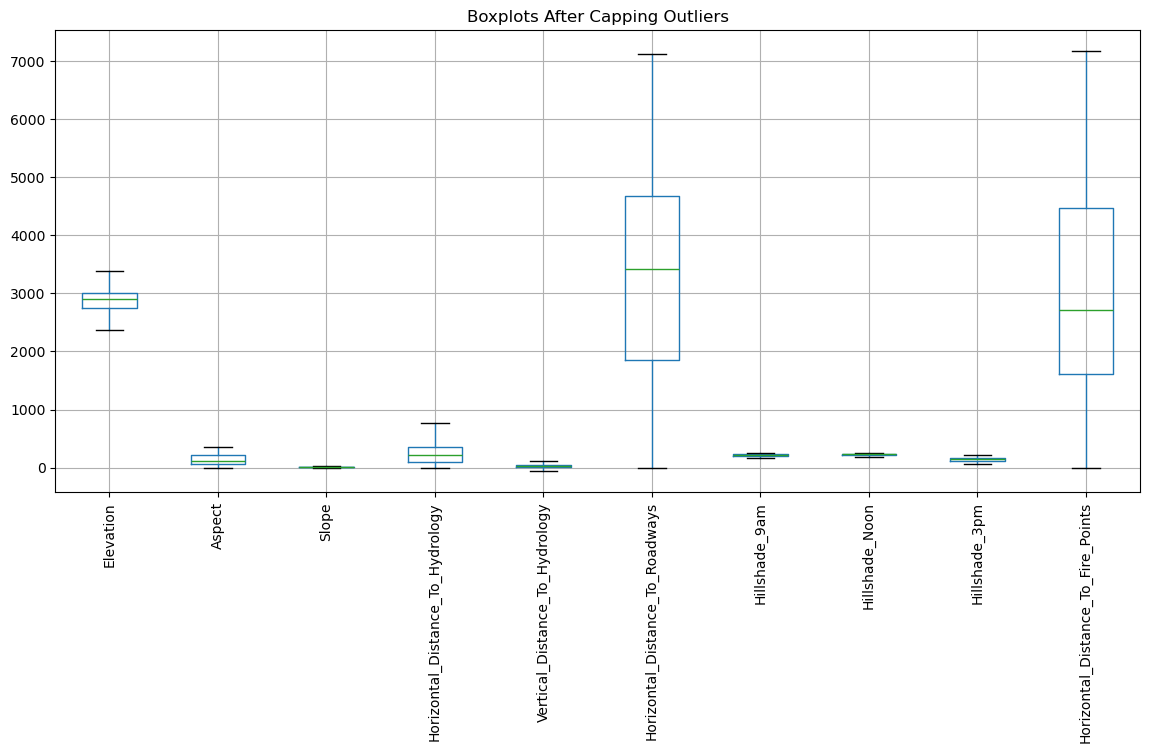

In [19]:
plt.figure(figsize=(14, 6))
df_capped[numerical_cols].boxplot(rot=90)
plt.title("Boxplots After Capping Outliers")
plt.show()

### Outlier Detection and Handling

##### Outliers were detected using the IQR method and visualized using boxplots.
##### Given the nature of geospatial data, extreme values are expected and do not necessarily indicate errors. Therefore, instead of removing observations, outliers were handled using IQR-based capping to reduce their influence while preserving the overall data distribution.

In [20]:
df_capped[numerical_cols].skew()

Elevation                            -0.340370
Aspect                                0.689432
Slope                                 0.621361
Horizontal_Distance_To_Hydrology      0.792349
Vertical_Distance_To_Hydrology        0.861265
Horizontal_Distance_To_Roadways      -0.058240
Hillshade_9am                        -0.740409
Hillshade_Noon                       -0.505363
Hillshade_3pm                        -0.001189
Horizontal_Distance_To_Fire_Points    0.365249
dtype: float64

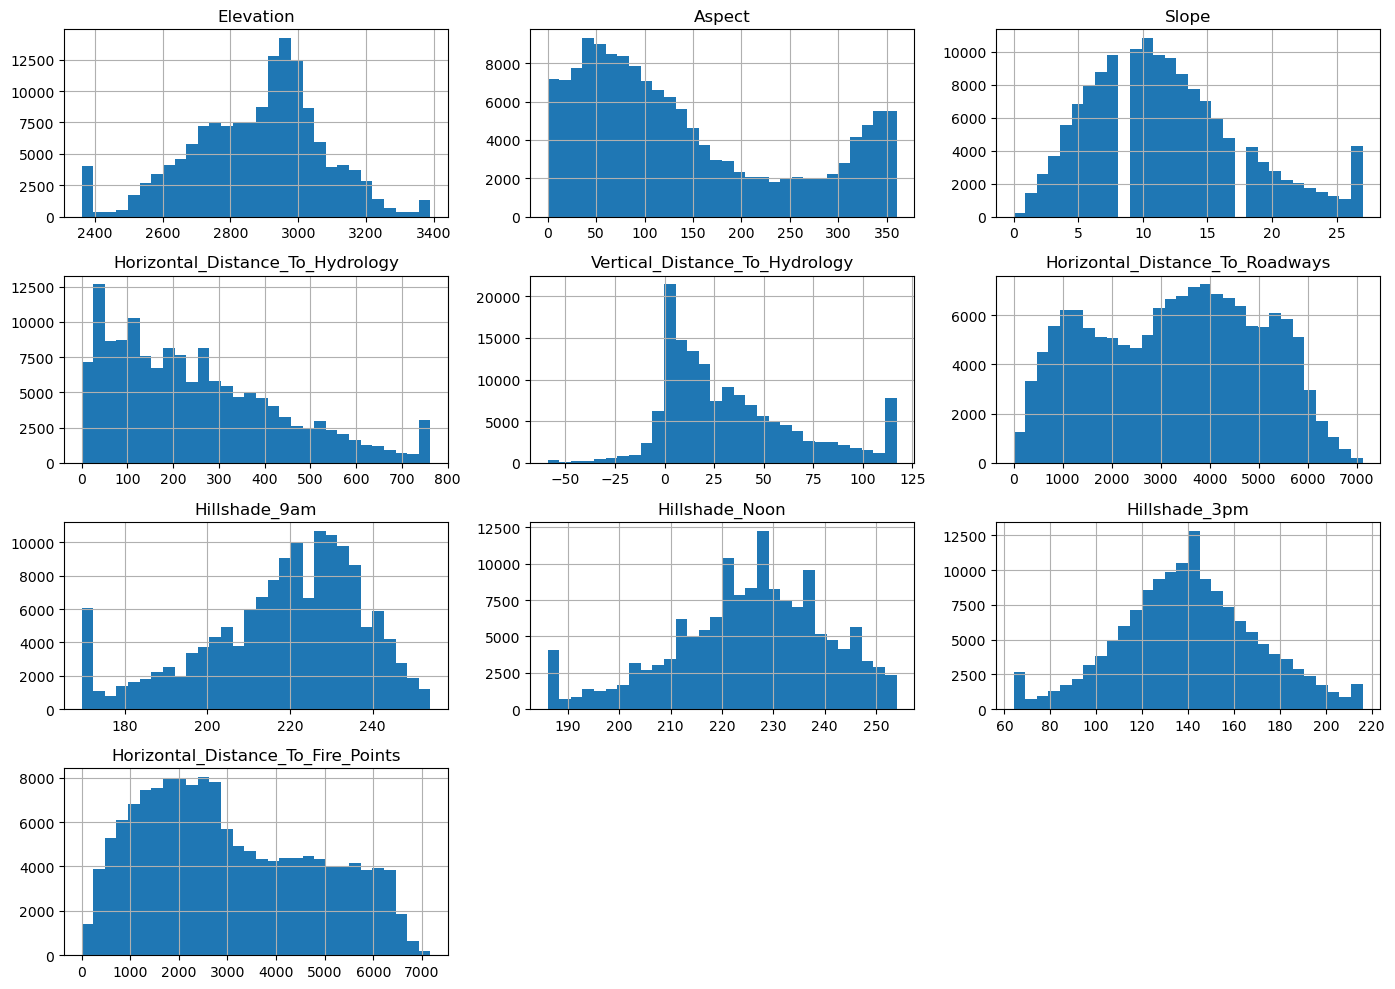

In [21]:
df_capped[numerical_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

### Skewness Analysis

##### After handling outliers using IQR-based capping, skewness was analyzed for all continuous numerical features. The skewness values were found to be within the acceptable range (|skew| < 1), indicating no severe distribution asymmetry. Therefore, no additional skewness transformations were applied.


In [22]:
df_capped.to_csv("/home/abishek-murugan/Project Folder/GUVI Projects/EcoType-Forest-Cover/data/processed/capped_forest_cover_data.csv",index=False)